In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
import sys
import os

# Add parent directory to sys.path
parent_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
sys.path.append(parent_dir)

In [6]:
from package_files.benefits_defns import *

In [17]:
# set font
plt.rcParams.update({'font.size': 14})

In [7]:
usdf_salary = pd.read_parquet('../data/us_10m_nointernship_2018_2024_benefits.parquet.gzip')

In [8]:
# rename usdf_salary
usdf = usdf_salary

In [10]:
usdf.columns

Index(['ID', 'CITY_NAME', 'COUNTY_NAME', 'STATE_NAME', 'NAICS_2022_2',
       'NAICS_2022_2_NAME', 'MIN_EDULEVELS_NAME', 'EMPLOYMENT_TYPE',
       'EMPLOYMENT_TYPE_NAME', 'IS_INTERNSHIP', 'REMOTE_TYPE',
       'REMOTE_TYPE_NAME', 'SKILLS', 'SKILLS_NAME', 'POSTED',
       'LAST_UPDATED_DATE', 'ONET', 'ONET_NAME', 'ONET_2019', 'ONET_2019_NAME',
       'SOC_2021_2_NAME', 'SOC_2021_2', 'MIN_YEARS_EXPERIENCE', 'COMPANY',
       'COMPANY_NAME', 'COMPANY_RAW', 'SALARY', 'EXPIRED', 'DURATION',
       'AI ROLE', 'wfh_wham_prob', 'wfh_wham', 'YEAR', 'EDU_ASSISTANCE',
       'PAID_LEAVE', 'WELLBEING', 'HEALTH_WELLBEING', 'PARENTAL_LEAVE',
       'CULTURE', 'REMOTE_KW', 'EXPERIENCE_BUCKET', 'LOG_SALARY'],
      dtype='object')

In [12]:
usdf['has_salary_info'] = usdf.apply(lambda x: 1 if pd.notnull(x['SALARY']) else 0, axis=1)

In [13]:
usdf.rename(columns = {'has_salary_info': 'HAS_SALARY_INFO'}, inplace=True)

In [22]:
benefits4

['EDU_ASSISTANCE',
 'PAID_LEAVE',
 'HEALTH_WELLBEING',
 'PARENTAL_LEAVE',
 'CULTURE',
 'REMOTE_KW']

In [21]:
benefit_colors

{'EDU_ASSISTANCE': '#41afaa',
 'PAID_LEAVE': '#466eb4',
 'HEALTH_WELLBEING': '#e6a532',
 'PARENTAL_LEAVE': '#00a0e1',
 'CULTURE': '#d7642c',
 'wfh_wham': '#af4b91',
 'REMOTE_KW': '#c765a6'}

,YEAR,AI ROLE,EDU_ASSISTANCE,HAS_SALARY_INFO
0,2018,False,False,0.160961
1,2018,False,True,0.151038
2,2018,True,False,0.068281
3,2018,True,True,0.049145
4,2019,False,False,0.184433


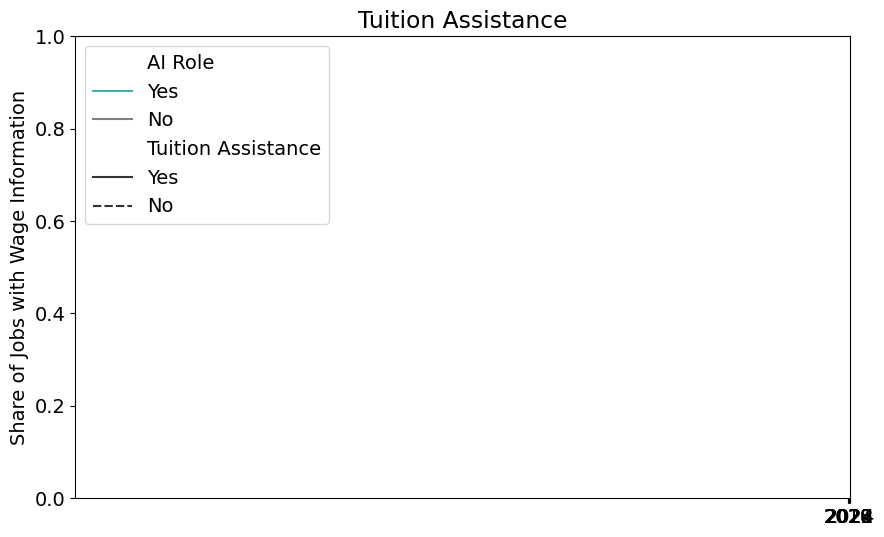

,YEAR,AI ROLE,PAID_LEAVE,HAS_SALARY_INFO
0,2018,False,False,0.149523
1,2018,False,True,0.250293
2,2018,True,False,0.059673
3,2018,True,True,0.164076
4,2019,False,False,0.168259


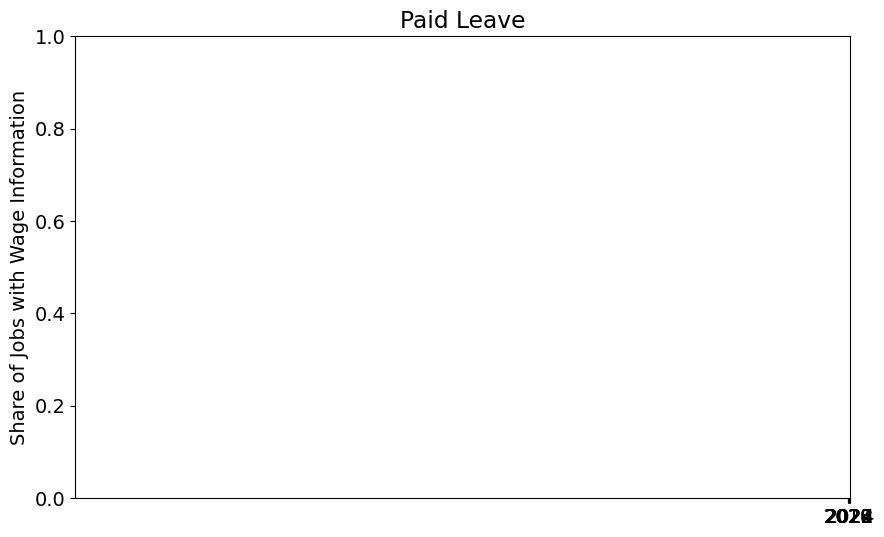

,YEAR,AI ROLE,HEALTH_WELLBEING,HAS_SALARY_INFO
0,2018,False,False,0.159401
1,2018,False,True,0.211550
2,2018,True,False,0.067349
3,2018,True,True,0.088983
4,2019,False,False,0.183209


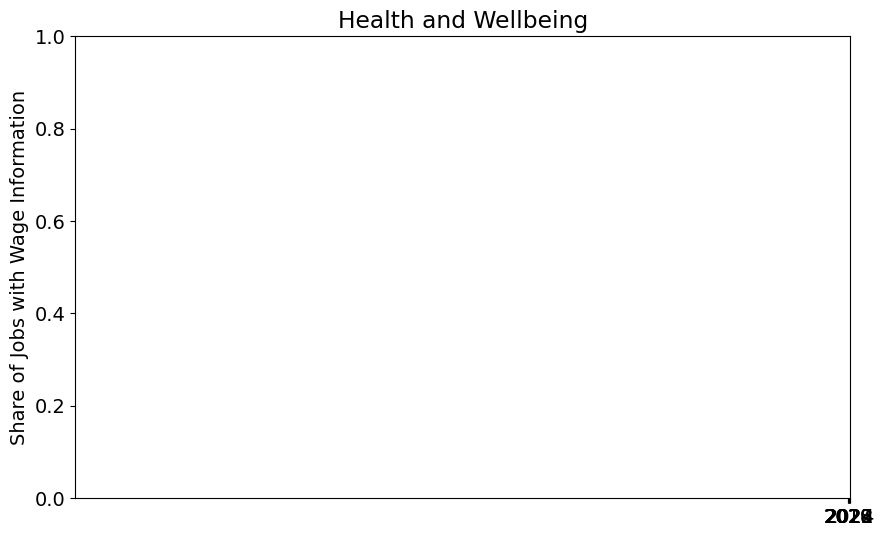

,YEAR,AI ROLE,PARENTAL_LEAVE,HAS_SALARY_INFO
0,2018,False,False,0.160727
1,2018,False,True,0.125307
2,2018,True,False,0.068037
3,2018,True,True,0.033113
4,2019,False,False,0.183044


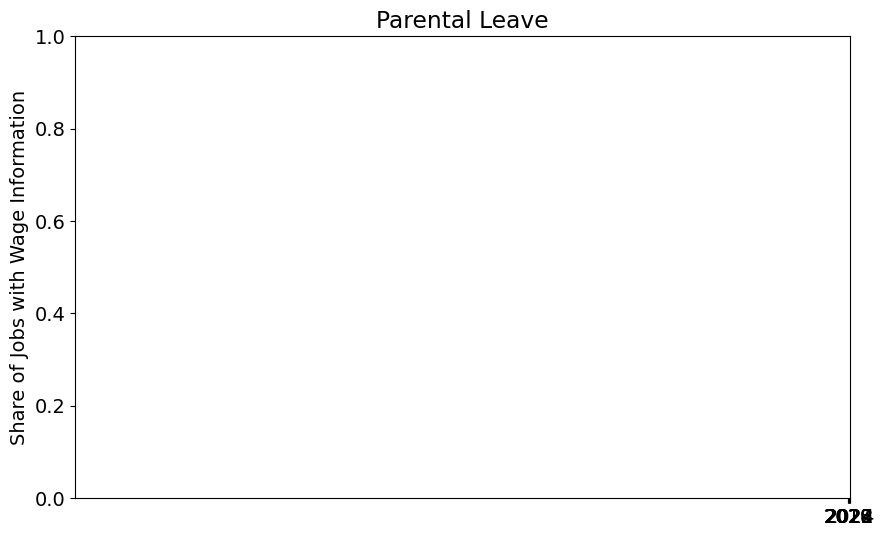

,YEAR,AI ROLE,CULTURE,HAS_SALARY_INFO
0,2018,False,False,0.163536
1,2018,False,True,0.094976
2,2018,True,False,0.071517
3,2018,True,True,0.026985
4,2019,False,False,0.187764


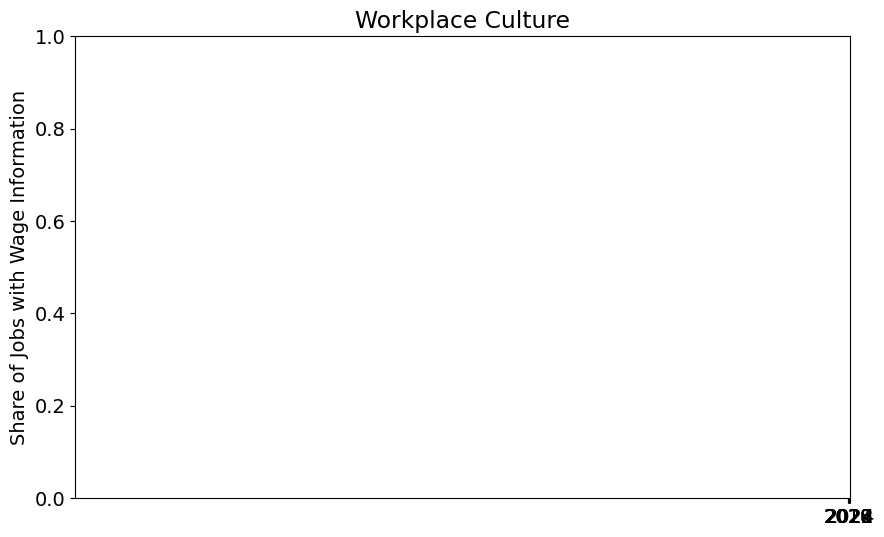

,YEAR,AI ROLE,REMOTE_KW,HAS_SALARY_INFO
0,2018,False,False,0.159121
1,2018,False,True,0.213726
2,2018,True,False,0.066310
3,2018,True,True,0.107784
4,2019,False,False,0.179030


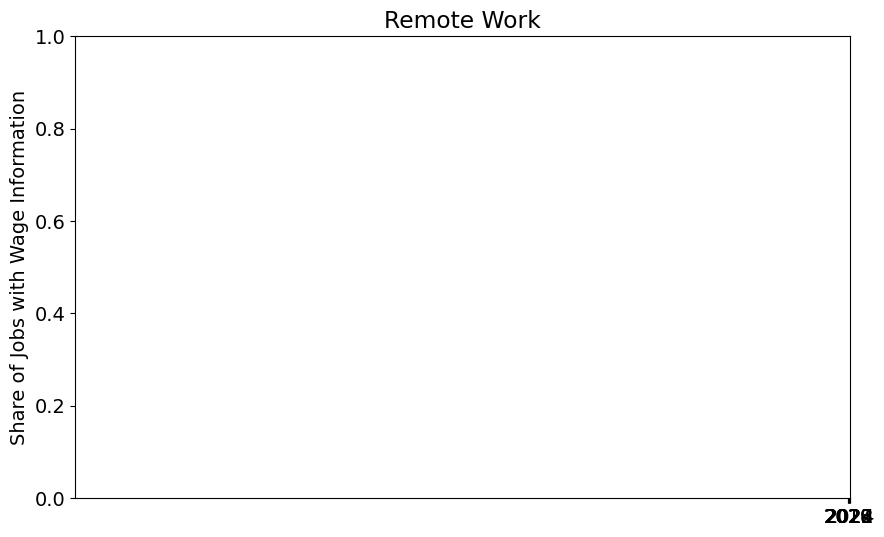

In [ ]:
for benefit in benefits4:
    grouped = usdf.groupby(['YEAR','AI ROLE', benefit])['HAS_SALARY_INFO'].mean().reset_index()
    grouped['HAS_SALARY_INFO'] = pd.to_numeric(grouped['HAS_SALARY_INFO'], errors='coerce')
    palette = [benefit_colors[benefit], 'gray']
    display(grouped.head())
    
    plt.figure(figsize = (10,6))
    sns.lineplot(
        data = grouped,
        x = 'YEAR', 
        y = 'HAS_SALARY_INFO', 
        hue = 'AI ROLE',
        style = benefit,
        markers=False,
        errorbar = None, 
        palette=palette,
        style_order = ['True', 'False'],
        hue_order=['True','False']
    )
    plt.xticks(grouped['YEAR'].unique())
    handles, labels = plt.gca().get_legend_handles_labels()
    new_handles = handles
    new_labels = ['AI Role', 'Yes','No', f'{benefits_labels_map[benefit]}','Yes','No']
    if benefit == benefits4[0]:
        plt.legend(handles = new_handles, labels = new_labels, loc='upper left')
    else: 
        plt.legend().remove()
    plt.xlabel(None)
    plt.ylabel('Share of Jobs with Wage Information')    
    plt.title(benefits_labels_map[benefit])
    plt.show()